<a href="https://colab.research.google.com/github/Chosencodes/Lung-Segmentation/blob/main/Lung_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !wget -q --show-progress https://msd-for-monai.s3-us-west-2.amazonaws.com/Task06_Lung.tar -O /content/Task06_Lung.tar
# !tar -xf /content/Task06_Lung.tar -C /content/
# !ls /content/Task06_Lung        # -> imagesTr  labelsTr  dataset.json

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# !mkdir -p "/content/drive/MyDrive/datasets"

# !cp /content/Task06_Lung.tar "/content/drive/MyDrive/datasets/Task06_Lung.tar"
# !ls -lh "/content/drive/MyDrive/datasets/"

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/datasets/Task06_Lung.tar" /content/

!tar -xf /content/Task06_Lung.tar -C /content/

data_path = "/content/Task06_Lung"

Mounted at /content/drive


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import os

In [3]:
root = Path("/content/Task06_Lung/imagesTr")
label = Path("/content/Task06_Lung/labelsTr")

In [4]:
sample_path = next(root.glob("lung*.nii.gz"))
sample_label_path = label / sample_path.name

In [5]:
data = nib.load(sample_path)
label = nib.load(sample_label_path)

In [6]:
ct_scan = data.get_fdata()
mask = label.get_fdata().astype(np.uint8)

In [7]:
print(data.shape)
print(label.shape)

print(nib.aff2axcodes(data.affine))
print(nib.aff2axcodes(label.affine))
print(data.header.get_zooms())
print(np.unique(mask))

(512, 512, 251)
(512, 512, 251)
('L', 'A', 'S')
('L', 'A', 'S')
(np.float32(0.929688), np.float32(0.929688), np.float32(1.2450199))
[0 1]


In [8]:
tumor_pixels = np.sum(mask == 1)
background_pixels = np.sum(mask == 0)

print(tumor_pixels)
print(background_pixels)

print("Tumor %:", tumor_pixels / mask.size * 100)

2973
65795171
Tumor %: 0.004518364530160608


Patient: lung_054.nii.gz
Tumor slices: [156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173
 174 175 176]


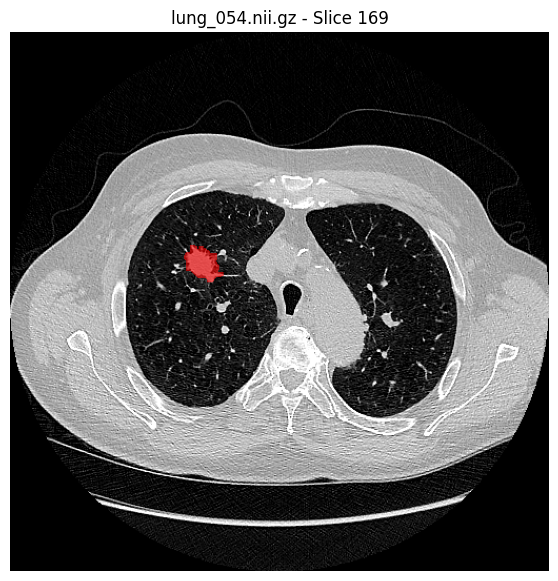

In [9]:
case = "lung_054.nii.gz"
print("Patient:", case)

image = nib.load(f"/content/Task06_Lung/imagesTr/{case}").get_fdata()
label = nib.load(f"/content/Task06_Lung/labelsTr/{case}").get_fdata().astype(np.uint8)

tumor_slices = np.where(label.sum(axis=(0, 1)) > 0)[0]

print("Tumor slices:", tumor_slices)

z = tumor_slices[np.argmax(label.sum(axis=(0, 1))[tumor_slices])]

plt.figure(figsize=(7,7))

plt.imshow(np.clip(image[:, :, z], -1000, 400).T,
           cmap="gray",
           origin="lower")

plt.imshow(np.ma.masked_where(label[:, :, z] == 0,
                              label[:, :, z]).T,
           cmap="autumn",
           alpha=0.6,
           origin="lower")

plt.title(f"{case} - Slice {z}")
plt.axis("off")
plt.show()

# **Preprocessing**

In [10]:
!pip install torchio nibabel scikit-learn tqdm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 23.6 MB/s eta 0:00:00


In [11]:
import torchio as tio
from sklearn.model_selection import train_test_split,KFold
from torch.utils.data import DataLoader

In [12]:
root = Path("/content/Task06_Lung/imagesTr")
label = Path("/content/Task06_Lung/labelsTr")

In [13]:
image_path = sorted(p for p in root.glob("lung*.nii.gz")  if not p.name.startswith("."))
label_path = sorted(p for p in label.glob("lung*.nii.gz") if not p.name.startswith("."))
print("images:", len(image_path), "labels:", len(label_path))

images: 63 labels: 63


In [14]:
def make_subject(image_path,label_path):
  subjects = []
  for img_path,lbl_path in zip(image_path,label_path):
    subject = tio.Subject(
        mri = tio.ScalarImage(img_path),
        mask = tio.LabelMap(lbl_path)
    )
    subjects.append(subject)
  return subjects

all_subject = make_subject(image_path,label_path)

In [15]:
base_transform = tio.Compose([
    tio.ToCanonical(),
    tio.Resample(1.5),
    tio.Clamp(-1000,400),
    tio.RescaleIntensity(
        out_min_max=(0, 1),
        in_min_max=(-1000, 400),
    ),
])

In [16]:
train_transform = tio.Compose([
    base_transform,
    tio.RandomFlip( axes=(0, 1, 2),flip_probability=0.5),
    tio.RandomAffine(scales=(0.9, 1.1),degrees=15,translation=8),
    tio.RandomGamma(log_gamma=(-0.3, 0.3), p=0.3),
    tio.RandomNoise(std=(0, 0.02), p=0.3),
    tio.RandomBlur(std=(0, 1), p=0.2),
    tio.RandomBiasField(p=0.2),
])

val_transform = base_transform

In [17]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)
patch_size = (64, 64, 64)

sampler = tio.LabelSampler(
                           patch_size=patch_size,
                           label_name="mask",
                           label_probabilities={0: 0.2, 1: 0.8})

def build_fold_loaders(train_subjects, val_subjects):
    train_ds = tio.SubjectsDataset(train_subjects, transform=train_transform)

    train_queue = tio.Queue(
        subjects_dataset=train_ds,
        max_length=128,
        samples_per_volume=48,
        sampler=sampler,
        num_workers=2,
        shuffle_subjects=True,
        shuffle_patches=True)

    train_loader = tio.SubjectsLoader(train_queue, batch_size=2)

    val_ds = tio.SubjectsDataset(val_subjects, transform=val_transform)
    val_loader = tio.SubjectsLoader(val_ds, batch_size=1, num_workers=2, shuffle=False)
    return train_loader, val_loader

print("Preprocessing ready.")

Preprocessing ready.


# **Model**

In [18]:
!pip install monai pytorch-lightning -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.9 MB/s eta 0:00:00


In [22]:
import torch
import pytorch_lightning as pl
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger, CSVLogger

In [19]:
def build_model():
    return UNet(
        spatial_dims=3,
        in_channels=1,
        out_channels=1,
        channels=(16,32,64,128,256),
        strides=(2, 2, 2, 2),
        num_res_units=2,
        dropout=0.05,
    )

In [20]:
# torch.set_float32_matmul_precision("high")

In [23]:
class LungTumorSegmentation(pl.LightningModule):
    def __init__(self, lr=5e-4):
        super().__init__()
        self.save_hyperparameters()
        self.model = build_model()

        self.loss_fn = DiceCELoss(sigmoid=True,  lambda_dice=0.8,lambda_ce=0.2)
        self.metrics = DiceMetric(include_background=True, reduction="mean")
        self.patch_size = patch_size

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        mri, mask = batch["mri"]["data"]
        batch["mask"]["data"].float()
        loss = self.loss_fn(self.model(mri), mask)
        self.log("train_loss", loss, prog_bar=True, batch_size=mri.shape[0])
        return loss

    def validation_step(self, batch, batch_idx):
        mri = batch["mri"]["data"]
        mask = batch["mask"]["data"].float()
        logits = sliding_window_inference(
            inputs=mri, roi_size=self.patch_size, sw_batch_size=2,
            predictor=self.forward, overlap=0.75, mode="gaussian")
        loss = self.loss_fn(logits, mask)
        pred = (torch.sigmoid(logits) > 0.5).float()
        self.metrics(pred, mask)

        tp = (pred * mask).sum()
        self.log("val_loss",   loss, prog_bar=True, batch_size=1)
        self.log("val_recall", tp / (mask.sum() + 1e-8), batch_size=1)
        self.log("val_prec",   tp / (pred.sum() + 1e-8), prog_bar=True, batch_size=1)
        return loss

    def on_validation_epoch_end(self):
        dice = self.metrics.aggregate().item()
        self.metrics.reset()
        self.log("val_dice", dice, prog_bar=True)
        print(f"Val dice: {dice:.4f}")

    def configure_optimizers(self):
        opt = torch.optim.AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=1e-5)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max",factor=0.5, patience=8)
        return {"optimizer": opt,
                "lr_scheduler": {"scheduler": sch,
                                 "monitor": "val_dice",
                                 "interval": "epoch",
                                 "frequency": 1}}

# **Training**

In [ ]:
# import shutil
# shutil.rmtree("/content/drive/MyDrive/lung_checkpoints", ignore_errors=True)

In [ ]:
import os, shutil, json
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger, CSVLogger
from google.colab import drive

drive.mount('/content/drive')

CKPT_ROOT = "/content/drive/MyDrive/lung_checkpoints"
LOG_DIR   = "/content/drive/MyDrive/lung_logs"
os.makedirs(CKPT_ROOT, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

def model_fingerprint():
    m = build_model()
    return [tuple(p.shape) for p in m.parameters()]

CURRENT_FINGERPRINT = model_fingerprint()

def fingerprint_matches(ckpt_dir):
    fp_file = os.path.join(ckpt_dir, "architecture.json")
    if not os.path.exists(fp_file):
        return False
    with open(fp_file) as f:
        saved = json.load(f)
    return saved == [list(s) for s in CURRENT_FINGERPRINT]

def save_fingerprint(ckpt_dir):
    with open(os.path.join(ckpt_dir, "architecture.json"), "w") as f:
        json.dump([list(s) for s in CURRENT_FINGERPRINT], f)

pl.seed_everything(42, workers=True)
fold_scores = []

print("Checking Drive for already-completed folds...")
for fold in range(1, 4):
    fold_dir = os.path.join(CKPT_ROOT, f"fold_{fold}")
    done_marker = os.path.join(fold_dir, "done.txt")
    if os.path.exists(done_marker):
        with open(done_marker) as f:
            print(f"Fold {fold}: already done ({f.read().strip()})")
    else:
        print(f"Fold {fold}: not yet completed")

for fold, (train_idx, val_idx) in enumerate(kf.split(all_subject), start=1):
    CKPT_DIR = os.path.join(CKPT_ROOT, f"fold_{fold}")
    os.makedirs(CKPT_DIR, exist_ok=True)
    done_marker = os.path.join(CKPT_DIR, "done.txt")

    if os.path.exists(done_marker):
        with open(done_marker) as f:
            score = float(f.read().split("=")[1])
        fold_scores.append(score)
        print(f"Fold {fold} already done ({score:.4f}) — skipping")
        continue

    print("=" * 60)
    print(f"Training Fold {fold}")
    print("Checkpoints are being written directly to Google Drive as training")
    print("runs — a Colab disconnect only costs you progress since the last")
    print("save_top_k checkpoint, nothing more, since Drive isn't wiped by Colab.")
    print("=" * 60)

    tr = [all_subject[i] for i in train_idx]
    va = [all_subject[i] for i in val_idx]
    train_loader, val_loader = build_fold_loaders(tr, va)
    print(f"train: {len(tr)}  validating on all {len(va)} subjects")

    model = LungTumorSegmentation(lr=1e-3)

    checkpoint = ModelCheckpoint(
        monitor="val_dice", mode="max",
        save_top_k=1,
        save_last=True,
        dirpath=CKPT_DIR,
        filename="best-{epoch}-{val_dice:.3f}"
        )

    step_checkpoint = ModelCheckpoint(
        dirpath=CKPT_DIR,
        filename="step-checkpoint",
        every_n_train_steps=100,
        save_top_k=1,
        save_last=False)

    early_stop = EarlyStopping(
        monitor="val_dice",
        mode="max",
        patience=25
        )

    lr_mon = LearningRateMonitor(logging_interval="epoch")

    loggers = [TensorBoardLogger(save_dir=LOG_DIR, name=f"fold{fold}"),
               CSVLogger(save_dir=LOG_DIR, name=f"fold{fold}_csv")]

    trainer = pl.Trainer(
        accelerator="gpu",
        devices=1,
        max_epochs=120,
        precision="32-true",
        gradient_clip_val=1.0,
        check_val_every_n_epoch=1,
        callbacks=[checkpoint, step_checkpoint, early_stop, lr_mon],
        logger=loggers, log_every_n_steps=5, num_sanity_val_steps=0
        )

    last = os.path.join(CKPT_DIR, "last.ckpt")
    step_ckpt = os.path.join(CKPT_DIR, "step-checkpoint.ckpt")

    resume_path = None
    candidates = [p for p in [last, step_ckpt] if os.path.exists(p)]
    if candidates:
        newest = max(candidates, key=os.path.getmtime)
        if fingerprint_matches(CKPT_DIR):
            resume_path = newest
            print(f"Resuming Fold {fold} from {newest}")
        else:
            print(f"Fold {fold}: architecture changed — starting fresh")
            shutil.rmtree(CKPT_DIR, ignore_errors=True)
            os.makedirs(CKPT_DIR, exist_ok=True)

    save_fingerprint(CKPT_DIR)

    try:
        trainer.fit(model, train_loader, val_loader, ckpt_path=resume_path)
    except KeyboardInterrupt:
        print(f"Interrupted during Fold {fold} — saving emergency checkpoint...")
        trainer.save_checkpoint(os.path.join(CKPT_DIR, "last.ckpt"))
        print("Saved directly to Drive. Re-run this cell to resume.")
        raise

    best = checkpoint.best_model_score.item()
    fold_scores.append(best)
    with open(done_marker, "w") as f:
        f.write(f"best_dice={best:.4f}")
    print(f"Fold {fold} Best Dice: {best:.4f}")
    print(f"Checkpoint saved permanently at: {checkpoint.best_model_path}")

print(f"\nPer-fold: {[round(s, 4) for s in fold_scores]}")
if len(fold_scores) == 3:
    import numpy as np
    print(f"Mean Dice: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

# **Evaluation**

In [26]:
import os, glob, json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from monai.inferers import sliding_window_inference
from monai.metrics import DiceMetric, MeanIoU, ConfusionMatrixMetric, HausdorffDistanceMetric

In [25]:
CKPT_ROOT = "/content/drive/MyDrive/lung_checkpoints"
OUT_DIR   = "/content/drive/MyDrive/lung_checkpoints/evaluation_results"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
def compute_case_metrics(pred: torch.Tensor,gt: torch.Tensor,spacing=None):
    """
    Computes evaluation metrics for a single 3D CT volume.

    Parameters
    ----------
    pred : torch.Tensor
        Binary prediction mask of shape (1, 1, H, W, D).

    gt : torch.Tensor
        Binary ground-truth mask of shape (1, 1, H, W, D).

    spacing : tuple, optional
        Physical voxel spacing (mm) used for HD95.
    """

    dice = dice_metric(pred, gt).item()
    iou = iou_metric(pred, gt).item()
    hd95 = hd95_metric(pred, gt, spacing=spacing).item()

    precision, recall, specificity = confusion_metric(pred, gt)[0].tolist()

    return dice, iou, hd95, precision, recall, specificity

In [ ]:
def evaluate_fold(fold: int, val_subjects, ckpt_dir: str) -> pd.DataFrame:
    best_ckpts = sorted(glob.glob(f"{ckpt_dir}/*best*.ckpt"))
    assert best_ckpts, f"No checkpoint found in {ckpt_dir}"
    ckpt_path = best_ckpts[-1]
    print(f"Fold {fold}: loading {ckpt_path}")
    model = LungTumorSegmentation.load_from_checkpoint(ckpt_path).cuda().eval()

    rows = []
    for subject in tqdm(val_subjects, desc=f"Fold {fold} eval"):
        subject_t = val_transform(subject)
        x = subject_t["mri"][tio.DATA].unsqueeze(0).cuda()
        y = subject_t["mask"][tio.DATA][0].numpy().astype(np.uint8)

        with torch.no_grad():
            logits = sliding_window_inference(
                inputs=x, roi_size=patch_size, sw_batch_size=2,
                predictor=model.forward, overlap=0.25, mode="gaussian")
            pred = (torch.sigmoid(logits) > 0.5)[0, 0].cpu().numpy().astype(np.uint8)

        spacing = subject_t["mri"].spacing
        m = compute_case_metrics(pred, y, spacing=spacing)
        m["case"] = subject["mri"].path.name
        m["fold"] = fold
        rows.append(m)

    return pd.DataFrame(rows)

all_results = []
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(all_subject)):
    fold = fold_idx + 1
    ckpt_dir = os.path.join(CKPT_ROOT, f"fold_{fold}")
    if not os.path.exists(ckpt_dir):
        print(f"Skipping fold {fold} — no checkpoint dir")
        continue
    va = [all_subject[i] for i in val_idx]
    df_fold = evaluate_fold(fold, va, ckpt_dir)
    all_results.append(df_fold)

results = pd.concat(all_results, ignore_index=True)
results.to_csv(os.path.join(OUT_DIR, "per_case_metrics.csv"), index=False)
print(f"\nEvaluated {len(results)} cases across {results['fold'].nunique()} fold(s)")


Fold 1: loading /content/drive/MyDrive/lung_checkpoints/fold_1/fold1_best-epoch33-val_dice0.299.ckpt


Fold 1 eval:   0%|          | 0/21 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
Fold 1 eval:   5%|▍         | 1/21 [00:11<03:56, 11.82s/it]/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:220: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
Fold 1 eval: 100%|██████████| 21/21 [04:41<00:00, 13.40s/it]


Fold 2: loading /content/drive/MyDrive/lung_checkpoints/fold_2/fold2_best-epoch46-val_dice0.366.ckpt


Fold 2 eval: 100%|██████████| 21/21 [04:31<00:00, 12.92s/it]


Fold 3: loading /content/drive/MyDrive/lung_checkpoints/fold_3/fold3_best-epoch27-val_dice0.505.ckpt


Fold 3 eval: 100%|██████████| 21/21 [04:08<00:00, 11.81s/it]


Evaluated 63 cases across 3 fold(s)


In [ ]:
def report(df: pd.DataFrame):
    metric_cols = ["dice", "iou", "hd95_mm", "precision", "recall",
                  "specificity", "volumetric_similarity"]
    print("=" * 65)
    print("OVERALL (all folds combined)")
    print("=" * 65)
    for m in metric_cols:
        vals = df[m].dropna()
        print(f"  {m:24s}: {vals.mean():.4f} ± {vals.std():.4f}  (n={len(vals)})")
    if df["fold"].nunique() > 1:
        print("\n" + "=" * 65)
        print("PER-FOLD Dice (for cross-validation reporting)")
        print("=" * 65)
        fold_dice = df.groupby("fold")["dice"].mean()
        for f, d in fold_dice.items():
            print(f"  Fold {f}: {d:.4f}")
        print(f"  Mean across folds: {fold_dice.mean():.4f} ± {fold_dice.std():.4f}")
    best = df.loc[df["dice"].idxmax()]
    worst = df.loc[df["dice"].idxmin()]
    print(f"\nBest  case: {best['case']}  (fold {int(best['fold'])}, Dice {best['dice']:.4f})")
    print(f"Worst case: {worst['case']}  (fold {int(worst['fold'])}, Dice {worst['dice']:.4f})")
    return best, worst

best_case, worst_case = report(results)

OVERALL (all folds combined)
  dice                    : 0.2876 ± 0.2533  (n=63)
  iou                     : 0.1971 ± 0.2016  (n=63)
  hd95_mm                 : 232.8424 ± 62.2164  (n=63)
  precision               : 0.2847 ± 0.2720  (n=63)
  recall                  : 0.4411 ± 0.3014  (n=63)
  specificity             : 0.9997 ± 0.0004  (n=63)
  volumetric_similarity   : 0.5660 ± 0.2975  (n=63)

PER-FOLD Dice (for cross-validation reporting)
  Fold 1: 0.2569
  Fold 2: 0.2398
  Fold 3: 0.3659
  Mean across folds: 0.2876 ± 0.0684

Best  case: lung_078.nii.gz  (fold 3, Dice 0.7764)
Worst case: lung_069.nii.gz  (fold 2, Dice 0.0000)


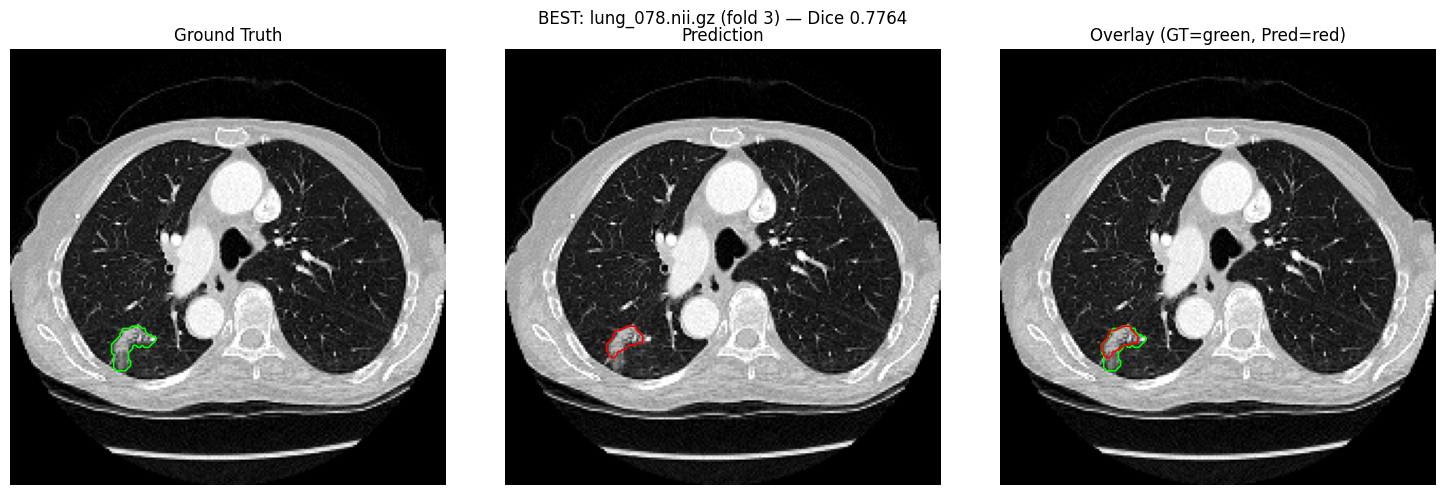

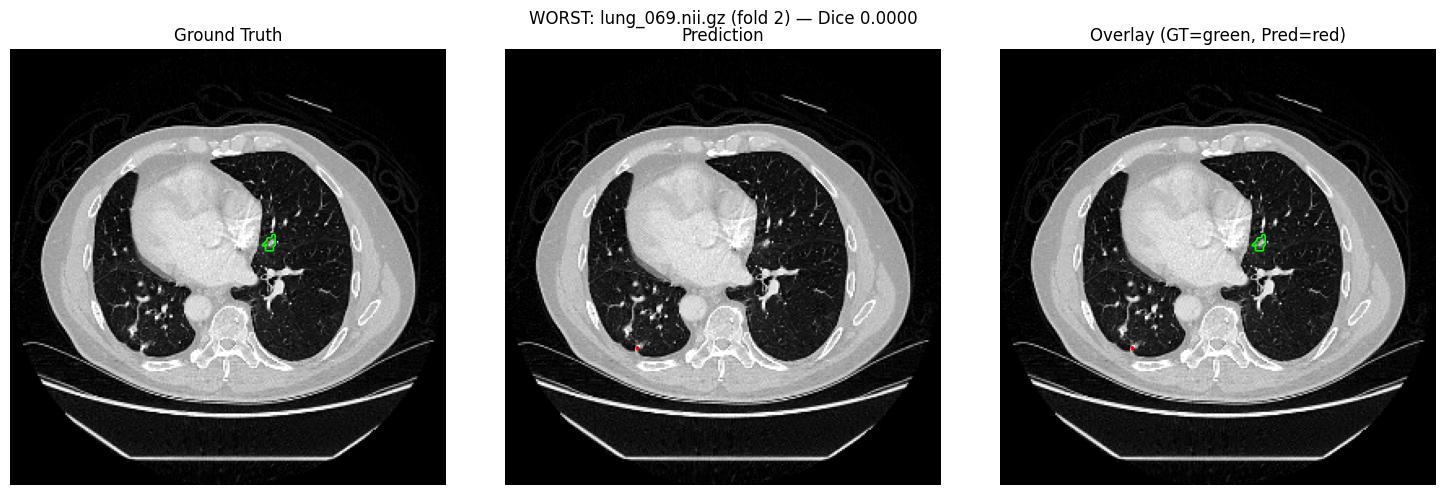

In [ ]:
def best_tumour_slice(mask: np.ndarray) -> int:
    if mask.sum() == 0:
        return mask.shape[2] // 2
    return int(mask.sum(axis=(0, 1)).argmax())

def render_case(case_name: str, fold: int, dice_score: float, tag: str):
    subject = next(s for s in all_subject if s["mri"].path.name == case_name)
    ckpt_dir = os.path.join(CKPT_ROOT, f"fold_{fold}")
    ckpt_path = sorted(glob.glob(f"{ckpt_dir}/*best*.ckpt"))[-1]
    model = LungTumorSegmentation.load_from_checkpoint(ckpt_path).cuda().eval()

    subject_t = val_transform(subject)
    x = subject_t["mri"][tio.DATA].unsqueeze(0).cuda()
    ct = subject_t["mri"][tio.DATA][0].numpy()
    gt = subject_t["mask"][tio.DATA][0].numpy().astype(np.uint8)

    with torch.no_grad():
        logits = sliding_window_inference(x, patch_size, 2, model.forward,
                                          overlap=0.25, mode="gaussian")
        pred = (torch.sigmoid(logits) > 0.5)[0, 0].cpu().numpy().astype(np.uint8)

    z = best_tumour_slice(gt if gt.sum() > 0 else pred)
    ct_s, gt_s, pr_s = ct[:, :, z].T, gt[:, :, z].T, pred[:, :, z].T

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax in axes:
        ax.imshow(ct_s, cmap="gray", origin="lower"); ax.axis("off")
    axes[0].contour(gt_s, levels=[0.5], colors="lime", linewidths=1.2)
    axes[0].set_title("Ground Truth")
    axes[1].contour(pr_s, levels=[0.5], colors="red", linewidths=1.2)
    axes[1].set_title("Prediction")
    axes[2].contour(gt_s, levels=[0.5], colors="lime", linewidths=1.2)
    axes[2].contour(pr_s, levels=[0.5], colors="red", linewidths=1.2)
    axes[2].set_title("Overlay (GT=green, Pred=red)")
    fig.suptitle(f"{tag.upper()}: {case_name} (fold {fold}) — Dice {dice_score:.4f}")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"{tag}_case.png"), dpi=120, bbox_inches="tight")
    plt.show()

render_case(best_case["case"], int(best_case["fold"]), best_case["dice"], "best")
render_case(worst_case["case"], int(worst_case["fold"]), worst_case["dice"], "worst")


Fold 1: combined 10 log files, columns found: ['epoch', 'lr-Adam', 'step', 'train_loss', 'val_dice', 'val_loss', 'val_prec', 'val_recall', 'lr-AdamW']


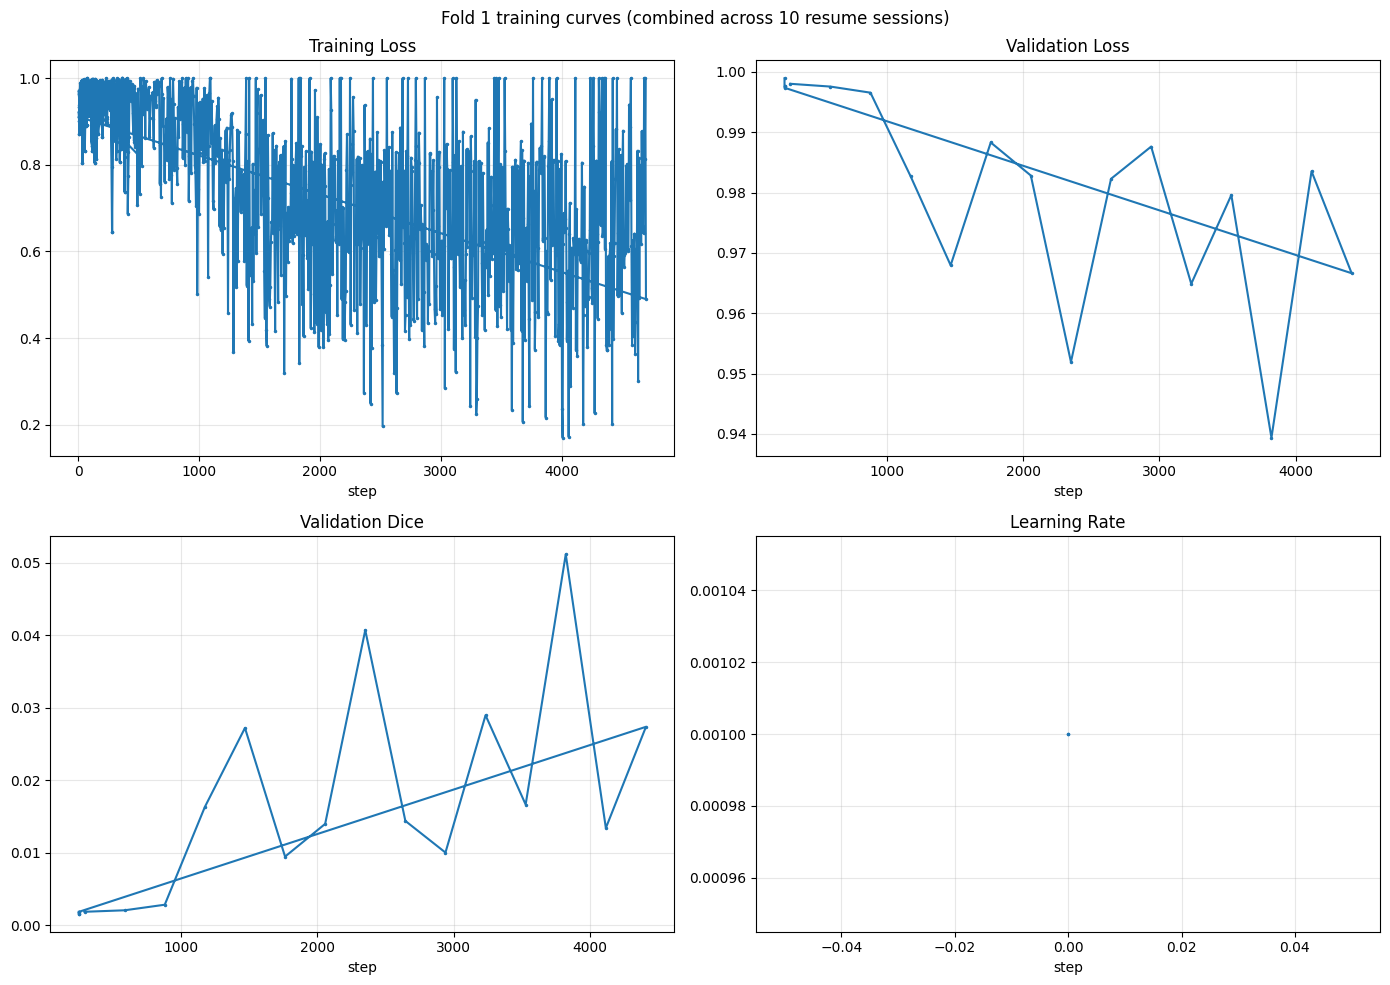

No logs for fold 2
No logs for fold 3


In [ ]:
import glob, pandas as pd
import matplotlib.pyplot as plt

LOG_DIR = "/content/drive/MyDrive/lung_logs"

def plot_training_curves(fold: int):
    csvs = sorted(glob.glob(f"{LOG_DIR}/fold{fold}_csv/version_*/metrics.csv"))
    if not csvs:
        print(f"No logs for fold {fold}"); return

    # Concatenate every resume session's log into one continuous history
    dfs = [pd.read_csv(c) for c in csvs]
    df = pd.concat(dfs, ignore_index=True)
    print(f"Fold {fold}: combined {len(csvs)} log files, columns found: {df.columns.tolist()}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    panels = [("train_loss", "Training Loss", axes[0,0]),
             ("val_loss", "Validation Loss", axes[0,1]),
             ("val_dice", "Validation Dice", axes[1,0]),
             ("lr-AdamW", "Learning Rate", axes[1,1])]

    for col, title, ax in panels:
        if col in df.columns:
            sub = df[["step", col]].dropna()
            if len(sub):
                ax.plot(sub["step"], sub[col], marker=".", markersize=3)
            else:
                ax.text(0.5, 0.5, "no data logged", ha="center", va="center", transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, "column not found", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title); ax.set_xlabel("step"); ax.grid(alpha=0.3)

    fig.suptitle(f"Fold {fold} training curves (combined across {len(csvs)} resume sessions)")
    fig.tight_layout()
    fig.savefig(f"/content/drive/MyDrive/lung_checkpoints/evaluation_results/fold{fold}_training_curves.png",
               dpi=120, bbox_inches="tight")
    plt.show()

for fold in [1, 2, 3]:
    plot_training_curves(fold)

In [ ]:
print(f"""
PERFORMANCE DISCUSSION
=======================
Dataset: Task06_Lung, {results['case'].nunique()} cases evaluated,
tumour fraction ~0.0034% of voxels (extreme class imbalance).

Overall Dice: {results['dice'].mean():.4f} ± {results['dice'].std():.4f}
Overall IoU : {results['iou'].mean():.4f} ± {results['iou'].std():.4f}
Overall HD95: {results['hd95_mm'].mean():.4f} mm ± {results['hd95_mm'].std():.4f}

Recall (sensitivity) : {results['recall'].mean():.4f} — ability to find tumour
Precision            : {results['precision'].mean():.4f} — freedom from false alarms
Volumetric Similarity: {results['volumetric_similarity'].mean():.4f}

Interpretation: given the ~1:29,000 tumour-to-background voxel ratio, a naive
background-only classifier scores 99.9966% voxel accuracy while Dice = 0.
The recall/precision split above shows whether the model is under- or
over-segmenting relative to this baseline.
""")


PERFORMANCE DISCUSSION
Dataset: Task06_Lung, 63 cases evaluated,
tumour fraction ~0.0034% of voxels (extreme class imbalance).

Overall Dice: 0.2876 ± 0.2533
Overall IoU : 0.1971 ± 0.2016
Overall HD95: 232.8424 mm ± 62.2164

Recall (sensitivity) : 0.4411 — ability to find tumour
Precision            : 0.2847 — freedom from false alarms
Volumetric Similarity: 0.5660

Interpretation: given the ~1:29,000 tumour-to-background voxel ratio, a naive
background-only classifier scores 99.9966% voxel accuracy while Dice = 0.
The recall/precision split above shows whether the model is under- or
over-segmenting relative to this baseline.

